In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Load breast cancer dataset

data = load_breast_cancer()

X = data.data
y = data.target

# Convert to DataFrame for easier viewing

df = pd.DataFrame(X, columns=data.feature_names)

# Add target column

df['target'] = y

# Display first 5 rows

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
# Basic dataset information

print("Dataset Shape:", df.shape)

print("\nFeature Names:")
print(data.feature_names)

print("\nClass Labels:")
print(data.target_names)

# Check class distribution

print("\nTarget Distribution:")
print(df['target'].value_counts())

Dataset Shape: (569, 31)

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Class Labels:
['malignant' 'benign']

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [5]:
# Different numbers of trees to test

tree_values = [1, 5, 10, 50, 100]

# Store accuracies

train_accuracies = []
test_accuracies = []

for n_trees in tree_values:

    # Create model

    model = RandomForestClassifier(
        n_estimators=n_trees,
        random_state=42
    )

    # Train model

    model.fit(X_train, y_train)

    # Predictions

    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Accuracy scores

    train_acc = accuracy_score(y_train, train_predictions)
    test_acc = accuracy_score(y_test, test_predictions)

    # Store results

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Trees: {n_trees}")
    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")
    print("-" * 40)

Trees: 1
Training Accuracy: 0.9582
Testing Accuracy: 0.9386
----------------------------------------
Trees: 5
Training Accuracy: 0.9824
Testing Accuracy: 0.9474
----------------------------------------
Trees: 10
Training Accuracy: 0.9978
Testing Accuracy: 0.9561
----------------------------------------
Trees: 50
Training Accuracy: 1.0000
Testing Accuracy: 0.9649
----------------------------------------
Trees: 100
Training Accuracy: 1.0000
Testing Accuracy: 0.9649
----------------------------------------


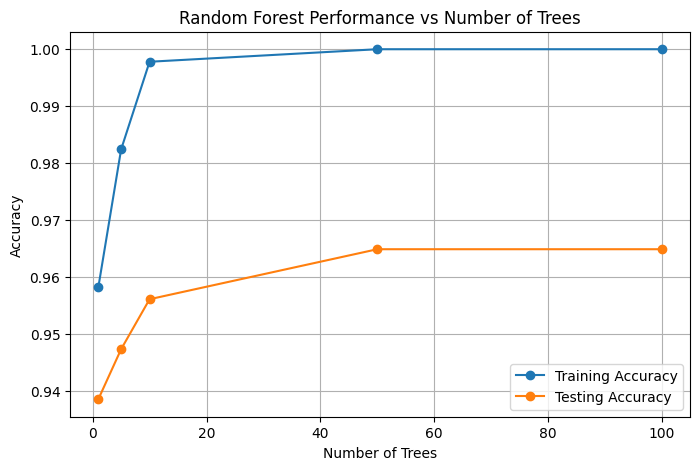

In [6]:
# Plot results

plt.figure(figsize=(8, 5))

plt.plot(tree_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(tree_values, test_accuracies, marker='o', label='Testing Accuracy')

plt.title('Random Forest Performance vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.legend()

plt.grid(True)

plt.show()

In [7]:
# Final model

final_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

final_model.fit(X_train, y_train)

# Predictions

final_predictions = final_model.predict(X_test)

In [8]:
# Detailed evaluation metrics

print(classification_report(y_test, final_predictions))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



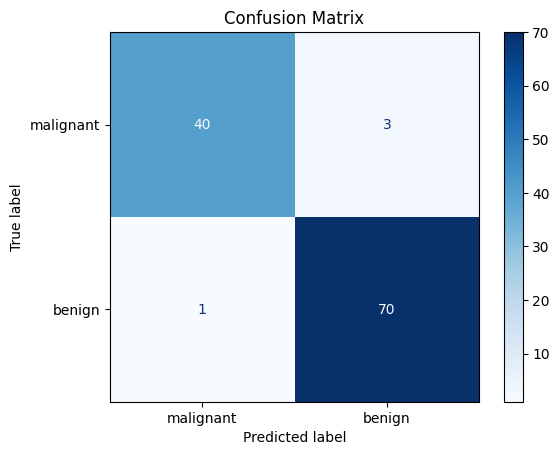

In [9]:
# Confusion matrix

cm = confusion_matrix(y_test, final_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [10]:
# Get feature importance

importance = final_model.feature_importances_

# Create DataFrame

feature_importance_df = pd.DataFrame({
    'Feature': data.feature_names,
    'Importance': importance
})

# Sort values

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features

print(feature_importance_df.head(10))

                 Feature  Importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


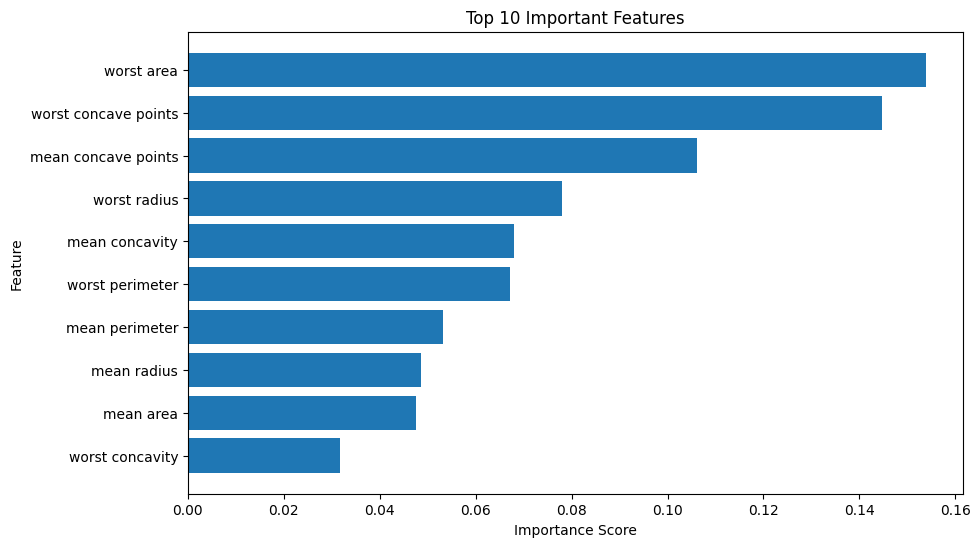

In [11]:
# Plot top 10 important features

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(top_features['Feature'], top_features['Importance'])

plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

plt.gca().invert_yaxis()

plt.show()

# Ethical Considerations

Although Random Forest models can achieve high accuracy in medical diagnosis tasks, ethical concerns remain important.

Potential issues include:

- Bias in the dataset may lead to unfair predictions.
- Medical datasets may not represent all populations equally.
- Incorrect predictions could affect patient outcomes.
- Random Forest models are less interpretable than simple decision trees.

To improve ethical AI practice, datasets should be diverse, transparent, and carefully validated.

# Conclusion

This tutorial demonstrated how Random Forest classification performance changes as the number of trees increases.

The experiments showed that increasing the number of trees generally improves testing accuracy and reduces overfitting compared to a single decision tree.

Feature importance analysis also showed which medical measurements contributed most strongly to predictions.

Random Forest is therefore a powerful and reliable machine learning method for classification problems.